In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [ ]:
df.isnull().sum()

df.info()

df.describe()

df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


0

In [ ]:
df.drop(columns=['Overview', 'Original_Language'], inplace=True)

df['Release_Date'] = pd.to_datetime(df['Release_Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Release_Date  9827 non-null   datetime64[ns]
 1   Title         9827 non-null   object        
 2   Popularity    9827 non-null   float64       
 3   Vote_Count    9827 non-null   int64         
 4   Vote_Average  9827 non-null   float64       
 5   Genre         9827 non-null   object        
 6   Poster_Url    9827 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 537.5+ KB


In [ ]:
df['Year'] = df['Release_Date'].dt.year

df['Month'] = df['Release_Date'].dt.month_name()

df.head()


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Poster_Url,Year,Month
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021,December
1,2022-03-01,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022,March
2,2022-02-25,No Exit,2618.087,122,6.3,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022,February
3,2021-11-24,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021,November
4,2021-12-22,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021,December


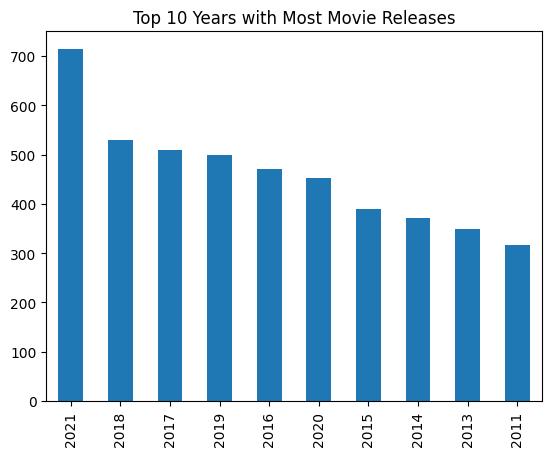

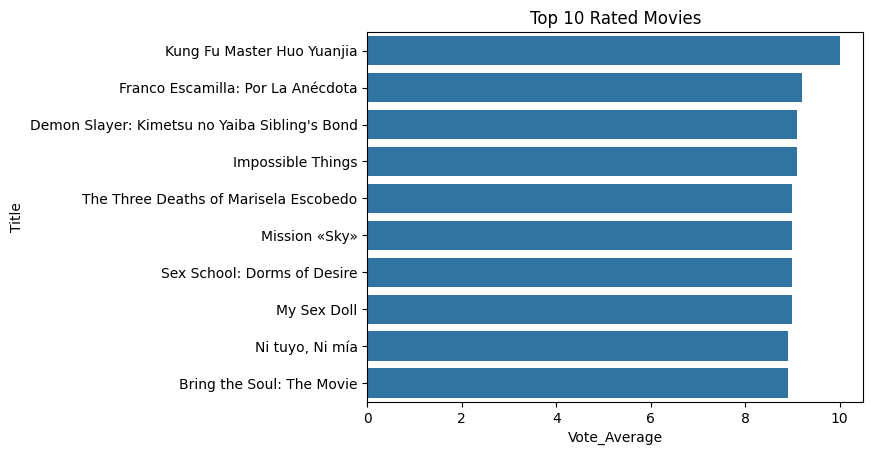

In [ ]:
df['Year'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Years with Most Movie Releases')
plt.show()

top_rated = df.nlargest(10, 'Vote_Average')[['Title', 'Vote_Average']]
sns.barplot(x='Vote_Average', y='Title', data=top_rated)
plt.title('Top 10 Rated Movies')
plt.show()